In [1]:
# --- 設定 ---
ENV_ID = "MountainCarContinuous-v0" # 環境 ID
GIF_FILENAME = "cartpole_random_episode.gif" # 輸出的 GIF 檔名
FRAME_DURATION_MS = 40 # 每幀顯示的毫秒數 (40ms = 25 FPS)
MAX_FRAMES = 500 # 最多儲存的幀數 (CartPole 通常一個 episode 不會太長)

# --- 創建環境 ---
# render_mode='rgb_array' 模式是儲存 GIF 必需的

import gym
import matplotlib.pyplot as plt
env = gym.make(ENV_ID, render_mode='rgb_array')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
from torch.distributions import Normal
from IPython.display import clear_output
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

class ActorCriticNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=64):
        super(ActorCriticNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        # 輸出動作分佈的平均值
        self.actor_mean = nn.Linear(hidden_size, action_size)
        # 可學習的 log std 參數
        self.actor_log_std = nn.Parameter(torch.zeros(action_size))
        # 評價網路不變
        self.critic_head = nn.Linear(hidden_size, 1)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        mean = self.actor_mean(x)
        # 將 log_std exponentiate 並 broadcast 到各樣本
        std = self.actor_log_std.exp().expand_as(mean)
        value = self.critic_head(x)
        return mean, std, value

class ActorCriticAgent:
    def __init__(self, state_size, action_size, learning_rate=1e-3, gamma=0.99):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.best_reward = -float('inf')
        self.rewards = list()
        self.model = ActorCriticNetwork(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

    def take_action(self, state, greedy=True):
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            mean, std, _ = self.model(state)
            dist = Normal(mean, std)
            if greedy:
                # 訓練時使用隨機行為（sample）
                action = dist.sample()
            else:
                # 測試時使用貪婪行為（取 mean）
                action = mean
            return action.cpu().numpy().flatten()

    def actor_loss(self, log_probs, advantages):
        return -(log_probs * advantages).mean()

    def critic_loss(self, values, returns):
        return F.mse_loss(values, returns)

    def fit(self, env, num_episodes=1000, max_steps=200):
        for episode in range(num_episodes):
            try:
                state = env.reset()
                rewards = []
                log_probs = []
                values = []
                done = False
                step = 0

                while not done and step < max_steps:
                    action = self.take_action(state)  # 連續動作
                    next_state, reward, done, _ = env.step(action)
                    
                    # 計算 log_prob 和 value
                    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                    mean, std, value = self.model(state_tensor)
                    dist = Normal(mean, std)
                    action_tensor = torch.FloatTensor(action).to(self.device)
                    log_prob = dist.log_prob(action_tensor).sum(dim=-1)  # 多維動作 sum
                    
                    rewards.append(reward)
                    log_probs.append(log_prob)
                    values.append(value)
                    state = next_state
                    step += 1

                # 計算 Returns
                returns = []
                R = 0
                for r in reversed(rewards):
                    R = r + self.gamma * R
                    returns.insert(0, R)
                returns = torch.tensor(returns).float().to(self.device)
                values = torch.cat(values).squeeze()
                advantages = (returns - values).detach()  # Advantage estimation

                log_probs = torch.stack(log_probs)
                actor_loss = self.actor_loss(log_probs, advantages)
                critic_loss = self.critic_loss(values, returns)
                loss = actor_loss + critic_loss

                # 更新
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                reward_sum = sum(rewards)
                print(f"Episode: {episode + 1}, Loss: {loss.item():.4f}, Reward: {reward_sum:.2f}")

                # 儲存最佳模型
                if reward_sum > self.best_reward:
                    self.best_reward = reward_sum
                    self.save("best_actor_critic_continuous.pth")
                    self.state_dict = self.model.state_dict()
                print(f"新最佳獎勵: {self.best_reward}，已儲存模型")

                self.rewards.append(reward_sum)
                plt.plot(self.rewards)
                plt.xlabel('Episode')
                plt.ylabel('Reward')
                plt.title('Training Progress')
                plt.show()
                clear_output(wait=True)

            except KeyboardInterrupt:
                break

        # 訓練結束後載入最佳權重
        self.model.load_state_dict(self.state_dict)

    def save(self, filepath):
        torch.save(self.model.state_dict(), filepath)

    def load(self, filepath):
        self.model.load_state_dict(torch.load(filepath))
        self.model.eval()


In [5]:
class Env:
    def __init__(self):
        self.env = gym.make("MountainCarContinuous-v0", render_mode='rgb_array')
        self.state = self.env.reset()[0]
        self.done = False
    def step(self, action):
        self.state, reward, terminated, truncated, info = self.env.step(action)
        self.done = terminated or truncated
        return self.state, reward, self.done, info
    def reset(self):
        self.state = self.env.reset()[0]
        self.done = False
        return self.state
    def render(self):
        return self.env.render()
    def close(self):
        self.env.close()

Episode: 2000, Loss: 1.5055, Reward: -7.43


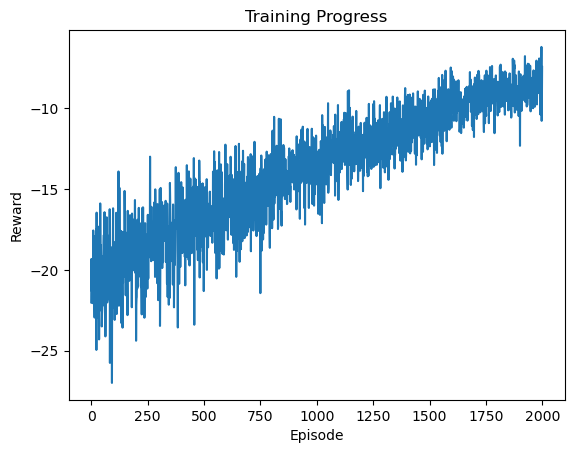

In [6]:
agent = ActorCriticAgent(2, 1, learning_rate=1e-3)
agent.fit(Env(), num_episodes=2000)

Episode: 269, Loss: 0.8048, Reward: -6.97


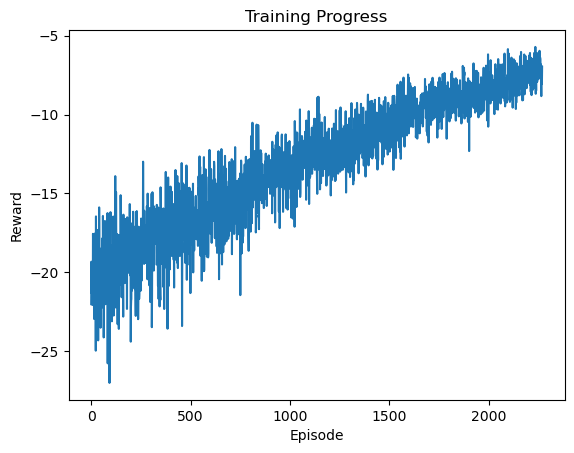

In [ ]:
agent.fit(Env(), num_episodes=8000)

In [ ]:
from PIL import Image
frames = []
ENV = Env()
done = False
state = ENV.reset()
actions = list()
while not done:
    action = agent.take_action(state, greedy=False)
    actions += [action]
    next_state, _, done, _ = ENV.step(action)
    state = next_state
    frame = ENV.render()
    frames.append(frame)
ENV.close()

image_objects = [Image.fromarray(np.uint8(frame)) for frame in frames]
image_objects[0].save(
                    GIF_FILENAME,
                    save_all=True,
                    append_images=image_objects[1:],
                    optimize=False, # 可以嘗試 optimize=True，但有時會導致顏色或透明度問題
                    duration=FRAME_DURATION_MS,
                    loop=0
                )